# Deep Momentum — Full Pipeline Run

Replication of Han & Qin (2026), "Bimodality Everywhere: International Evidence of Deep Momentum"

Pilot run: US, Canada, Australia

In [3]:
!pip install -q "pandas>=2.0" "numpy>=1.24" "xgboost>=2.0,<2.1" "scikit-learn>=1.3" requests python-dotenv pyarrow tqdm matplotlib seaborn   

In [4]:
import warnings
warnings.filterwarnings('ignore')

PILOT_COUNTRIES = ['TO', 'OL', 'AT']  # Canada, Norway, Austria
N_ENSEMBLE = 100  # paper uses 100
OOS_START = '2010-01-31'  # paper's OOS start

print('Pilot countries:', PILOT_COUNTRIES)
print(f'Ensemble size: {N_ENSEMBLE}')

Pilot countries: ['TO', 'OL', 'AT']
Ensemble size: 100


## Step 1: Data Fetch

## Step 2: Data Filtering

In [7]:
from data_filter import filter_country, check_country_eligibility
from config import COUNTRIES, DATA_DIR, CACHE_DIR
from pathlib import Path
import pandas as pd

for suffix in PILOT_COUNTRIES:
    _, country_name, _, _ = COUNTRIES[suffix]
    f = Path(DATA_DIR) / f'monthly_{suffix}.parquet'
    if not f.exists():
        print(f'No data for {suffix}')
        continue
    df = pd.read_parquet(f)
    filtered = filter_country(df, country_name)
    filtered.to_parquet(Path(CACHE_DIR) / f'filtered_{suffix}.parquet', index=False)
    eligible, reason = check_country_eligibility(filtered, suffix)
    print(f'  Eligible: {eligible} — {reason}')


  Canada: 848 stocks, 191116 obs
    Zero volume filter: dropped 877 obs (0.5%)
    MCap missing filter: dropped 958 obs (0.5%)
    MCap bottom 5% filter: dropped 9624 obs (5.1%)
    Extreme return filter: dropped 93 obs (0.1%)
    Winsorize: clipped 3574 obs at [-0.3548, 0.6248]
    After all filters: 845 stocks, 178716 obs
  Eligible: False — min stocks/month = 2, need >=30

  Norway: 307 stocks, 48810 obs
    Zero volume filter: dropped 186 obs (0.4%)
    MCap missing filter: dropped 465 obs (1.0%)
    MCap bottom 5% filter: dropped 2518 obs (5.3%)
    Extreme return filter: dropped 43 obs (0.1%)
    Winsorize: clipped 906 obs at [-0.3846, 0.5370]
    After all filters: 304 stocks, 45291 obs
  Eligible: False — min stocks/month = 6, need >=30

  Austria: 98 stocks, 29173 obs
    Zero volume filter: dropped 291 obs (1.0%)
    MCap missing filter: dropped 404 obs (1.4%)
    MCap bottom 5% filter: dropped 1609 obs (5.7%)
    Extreme return filter: dropped 42 obs (0.2%)
    Winsorize: 

## Step 3: Feature Construction

In [8]:
from features import build_features
from config import COUNTRIES, CACHE_DIR
from pathlib import Path
import pandas as pd

cache_dir = Path(CACHE_DIR)
features_data = {}

for suffix in PILOT_COUNTRIES:
    filtered_path = cache_dir / f'filtered_{suffix}.parquet'
    if not filtered_path.exists():
        print(f'No filtered data for {suffix}, skipping')
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df = pd.read_parquet(filtered_path)
    df, feature_cols = build_features(df, country_name)
    
    # Save
    df.to_parquet(cache_dir / f'features_{suffix}.parquet', index=False)
    features_data[suffix] = (df, feature_cols)
    
print(f'\nFeatures built for {len(features_data)} countries')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

  Building features for Canada...
    Stocks: 845
    Total obs: 178716
    Complete obs (all features + label): 168637
    Feature cols: 16
  Building features for Norway...
    Stocks: 304
    Total obs: 45291
    Complete obs (all features + label): 41689
    Feature cols: 16
  Building features for Austria...
    Stocks: 97
    Total obs: 26729
    Complete obs (all features + label): 25574
    Feature cols: 16

Features built for 3 countries
Feature columns (16): ['zMOM_1', 'MMOM_1', 'SMOM_1', 'zMOM_3', 'MMOM_3', 'SMOM_3', 'zMOM_6', 'MMOM_6', 'SMOM_6', 'zMOM_9', 'MMOM_9', 'SMOM_9', 'zMOM_12', 'MMOM_12', 'SMOM_12', 'SIZE']


## Step 4: Model Training + Prediction

In [9]:
from model import run_walk_forward

predictions_data = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    
    print(f'\n{"="*60}')
    print(f'TRAINING: {country_name} (.{suffix})')
    print(f'{"="*60}')
    
    predictions = run_walk_forward(
        df, feature_cols,
        n_ensemble=N_ENSEMBLE,
        verbose=True,
    )
    
    if not predictions.empty:
        predictions.to_parquet(cache_dir / f'predictions_{suffix}.parquet', index=False)
        predictions_data[suffix] = predictions
        print(f'  Saved {len(predictions)} predictions')
    else:
        print(f'  No predictions generated')

print(f'\nPredictions generated for {len(predictions_data)} countries')


TRAINING: Canada (.TO)
    Training schedule: 27 retrainings
    First train: 2000-04-01
    Last train: 2026-04-01
    Training at 2000-04-01, predicting 12 months...
    Training at 2001-04-01, predicting 12 months...
    Training at 2002-04-01, predicting 12 months...
    Training at 2003-04-01, predicting 12 months...
    Training at 2004-04-01, predicting 12 months...
    Training at 2005-04-01, predicting 12 months...
    Training at 2006-04-01, predicting 12 months...
    Training at 2007-04-01, predicting 12 months...
    Training at 2008-04-01, predicting 12 months...
    Training at 2009-04-01, predicting 12 months...
    Training at 2010-04-01, predicting 12 months...
    Training at 2011-04-01, predicting 12 months...
    Training at 2012-04-01, predicting 12 months...
    Training at 2013-04-01, predicting 12 months...
    Training at 2014-04-01, predicting 12 months...
    Training at 2015-04-01, predicting 12 months...
    Training at 2016-04-01, predicting 12 months...

## Step 5: Portfolio Construction + Performance

In [10]:
from portfolio import run_all_strategies, print_performance_table

all_results = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]
    
    # Merge fwd_return into predictions
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    predictions = predictions.drop(columns=['fwd_return'], errors='ignore')
    predictions = predictions.merge(fwd, on=['symbol', 'date'], how='left')
    
    print(f'\n{"="*60}')
    print(f'{country_name}')
    print(f'{"="*60}')
    
    results = run_all_strategies(df, predictions, oos_start=OOS_START)
    print_performance_table(results)
    all_results[suffix] = results


Canada

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            18.5%     24.2%    0.765   1122.3%  -40.9%     3.08     194    3.9bp
XGB            23.2%     13.9%    1.672   3330.3%  -14.3%     6.69     192    6.8bp
RET            32.8%     17.0%    1.921  14759.5%  -15.5%     7.72     194    9.5bp
SRP            32.3%     16.8%    1.922  13824.4%  -20.0%     7.73     194    9.9bp

Norway

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            30.3%     26.5%    1.144   7243.9%  -34.3%     4.60     194    3.9bp
XGB            32.9%     20.6%    1.599  13336.3%  -26.1%     6.41     193    6.8bp
RET            32.3%     24.4%    1.323  10445.9%  -36.2%     5.31     193    9.7bp
SRP            33.5%     23.8%    1.406  12948.5% 

## Step 6: Full Report + Metrics

In [11]:
from metrics import full_report

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]
    
    # Merge fwd_return
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    preds = predictions.drop(columns=['fwd_return'], errors='ignore')
    preds = preds.merge(fwd, on=['symbol', 'date'], how='left')
    
    full_report(df, preds, all_results.get(suffix, {}), country_name)


FULL REPORT — Canada

--- Portfolio Performance (Table 5 equivalent) ---
Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months
---------------------------------------------------------------------------
MOM            18.5%     24.2%    0.765   1122.3%  -40.9%     3.08     194
XGB            23.2%     13.9%    1.672   3330.3%  -14.3%     6.69     192
RET            32.8%     17.0%    1.921  14759.5%  -15.5%     7.72     194
SRP            32.3%     16.8%    1.922  13824.4%  -20.0%     7.73     194

--- Bimodality (Table 2 equivalent) ---
  MOM:  HH=0.057  HL=0.030  LL=0.119  LH=0.074  BM=-0.036
  XGB:  HH=0.097  HL=0.069  LL=0.102  LH=0.064  BM=-0.033

--- Crash Rate ---
  MOM: 0.278
  XGB: 0.000
  RET: 0.000
  SRP: 0.000

--- Classification Accuracy (Table IA2 equivalent) ---
  Overall accuracy: 15.3%
  Precision H: 18.6%  Precision L: 19.7%
  Recall H: 25.4%  Recall L: 40.0%
  Pred ratio H: 13.6%  Pred ratio L: 20.8%

FULL REPORT — Norway

--- Portfolio Perf

## Plots

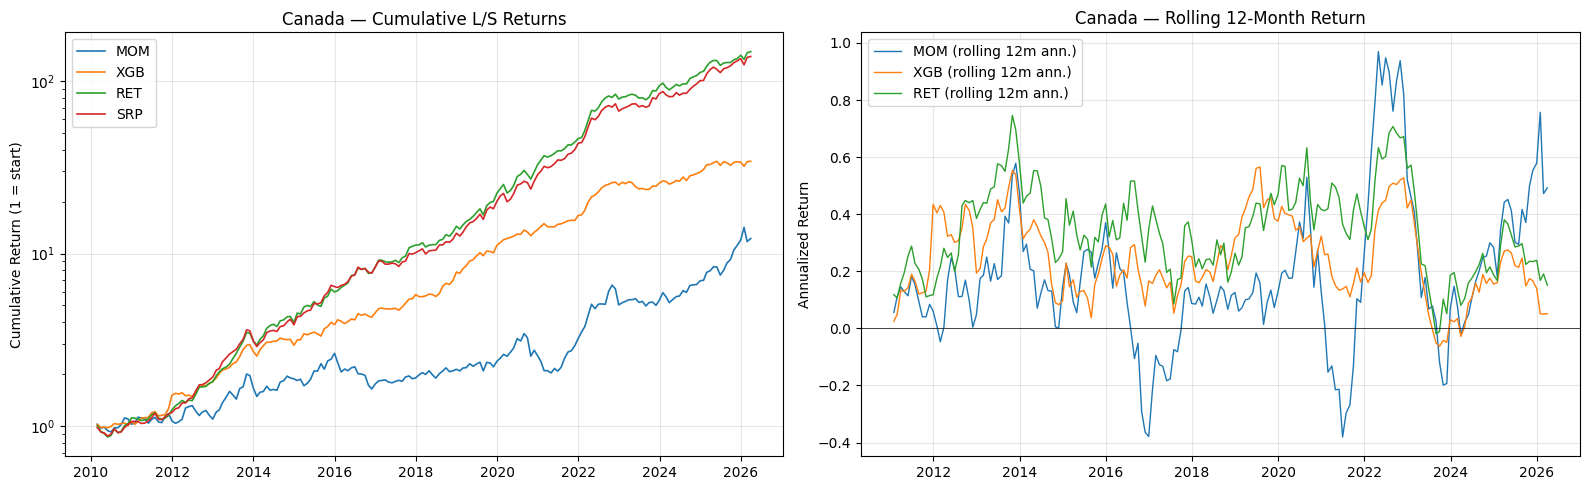

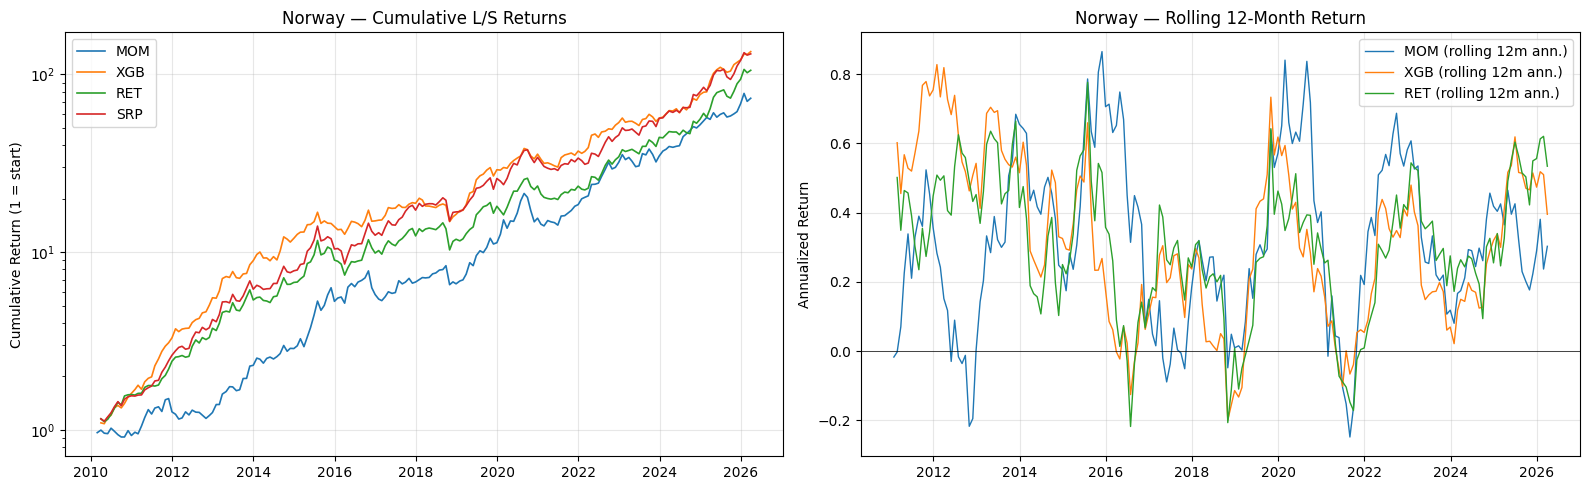

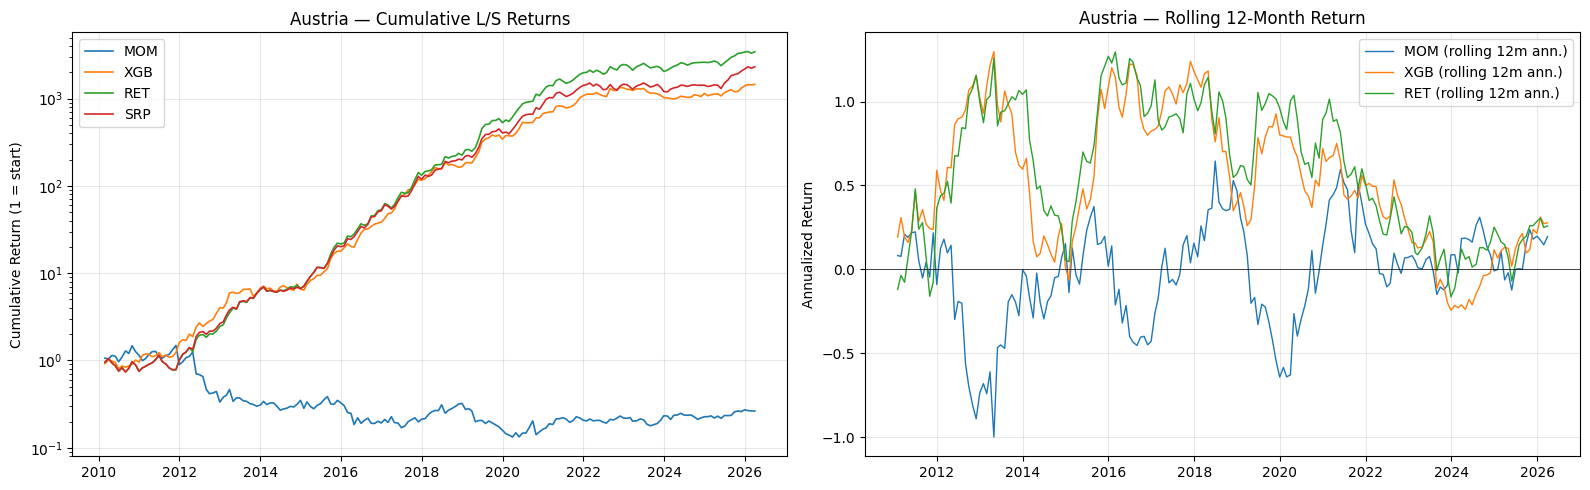

In [12]:
import matplotlib.pyplot as plt
import numpy as np

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Panel 1: Cumulative returns
    ax = axes[0]
    for name, color in [('MOM', '#1f77b4'), ('XGB', '#ff7f0e'), ('RET', '#2ca02c'), ('SRP', '#d62728')]:
        if name in all_results[suffix] and not all_results[suffix][name]['portfolio'].empty:
            port = all_results[suffix][name]['portfolio']
            cum = (1 + port['ls_ret']).cumprod()
            ax.plot(port['date'], cum, label=name, color=color, linewidth=1.2)
    
    ax.set_ylabel('Cumulative Return (1 = start)')
    ax.set_title(f'{country_name} — Cumulative L/S Returns')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_yscale('log')
    
    # Panel 2: Rolling 12-month return
    ax = axes[1]
    for name, color in [('MOM', '#1f77b4'), ('XGB', '#ff7f0e'), ('RET', '#2ca02c')]:
        if name in all_results[suffix] and not all_results[suffix][name]['portfolio'].empty:
            port = all_results[suffix][name]['portfolio']
            rolling = port['ls_ret'].rolling(12).mean() * 12
            ax.plot(port['date'], rolling, label=f'{name} (rolling 12m ann.)', 
                    color=color, linewidth=1)
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Annualized Return')
    ax.set_title(f'{country_name} — Rolling 12-Month Return')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'results/{suffix}_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print()

## Cross-Country Comparison (Table 5 equivalent)

In [13]:
print(f'{"Country":<15s} {"":>5s} {"MOM":>12s} {"XGB":>12s} {"RET":>12s} {"SRP":>12s}')
print(f'{"":>20s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s}')
print('-' * 75)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]
    
    parts = [f'{country_name:<15s}', f'{"":>5s}']
    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        if name in all_results[suffix] and all_results[suffix][name]['metrics']:
            m = all_results[suffix][name]['metrics']
            parts.append(f'{m["mean_annual"]:>5.1%}/{m["sharpe"]:>5.2f}')
        else:
            parts.append(f'{"N/A":>12s}')
    
    print('  '.join(parts))

Country                        MOM          XGB          RET          SRP
                     Ret / Sharpe Ret / Sharpe Ret / Sharpe Ret / Sharpe
---------------------------------------------------------------------------
Canada                  18.5%/ 0.77  23.2%/ 1.67  32.8%/ 1.92  32.3%/ 1.92
Norway                  30.3%/ 1.14  32.9%/ 1.60  32.3%/ 1.32  33.5%/ 1.41
Austria                 -1.0%/-0.03  50.0%/ 1.68  56.1%/ 1.76  53.4%/ 1.73


## Fixed-N Variant — Top 10 / Bottom 10 per Country per Month

Paper uses decile cuts (top/bottom 10%), which scales the portfolio with universe size. For practical execution we re-run all four strategies selecting a **fixed number** of names per country-month, ranked by each strategy's scalar signal:

- **MOM** — sort by `MOM_12`
- **XGB** — sort by `prob_10 − prob_1` (symmetric analogue of its class-based rule)
- **RET** — sort by `ret_score`
- **SRP** — sort by `srp_score`

Transaction costs (`TC_BPS = 15` one-way) are already applied inside `compute_turnover_cost`.

In [14]:
from portfolio import run_all_strategies, print_performance_table
from config import TOP_N_FIXED

all_results_fixed = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue

    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]

    # Merge fwd_return into predictions (same as decile pass)
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    predictions = predictions.drop(columns=['fwd_return'], errors='ignore')
    predictions = predictions.merge(fwd, on=['symbol', 'date'], how='left')

    print(f'\n{"="*60}')
    print(f'{country_name} — Fixed N={TOP_N_FIXED}')
    print(f'{"="*60}')

    results = run_all_strategies(df, predictions, oos_start=OOS_START, top_n=TOP_N_FIXED)
    print_performance_table(results)
    all_results_fixed[suffix] = results



Canada — Fixed N=10

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            19.7%     44.6%    0.441    389.3%  -77.1%     1.77     194    5.6bp
XGB            41.0%     33.4%    1.230  29117.7%  -44.2%     4.95     194   13.1bp
RET            56.4%     31.5%    1.791 354981.5%  -33.0%     7.20     194   13.0bp
SRP            50.1%     33.3%    1.503 120775.0%  -43.9%     6.04     194   13.1bp

Norway — Fixed N=10

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            25.7%     33.0%    0.779   2529.9%  -43.8%     3.13     194    4.4bp
XGB            43.0%     33.4%    1.288  37680.2%  -49.7%     5.17     193   11.0bp
RET            38.4%     32.0%    1.199  19664.1%  -42.1%     4.81     193   11.2bp
SRP            36.2%    

### Decile vs Fixed-N — Side-by-Side Sharpe Comparison

In [15]:
print(f'{"Country":<15s}  {"Strategy":<8s}  {"Decile Ret":>10s} {"Decile SR":>9s}  {"FixedN Ret":>10s} {"FixedN SR":>9s}  {"Delta SR":>8s}')
print('-' * 85)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results or suffix not in all_results_fixed:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]

    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        d = all_results[suffix].get(name, {}).get('metrics', {})
        f = all_results_fixed[suffix].get(name, {}).get('metrics', {})
        if not d or not f:
            continue
        delta = f['sharpe'] - d['sharpe']
        print(f'{country_name:<15s}  {name:<8s}  '
              f'{d["mean_annual"]:>9.1%} {d["sharpe"]:>9.3f}  '
              f'{f["mean_annual"]:>9.1%} {f["sharpe"]:>9.3f}  '
              f'{delta:>+8.3f}')
    print()


Country          Strategy  Decile Ret Decile SR  FixedN Ret FixedN SR  Delta SR
-------------------------------------------------------------------------------------
Canada           MOM           18.5%     0.765      19.7%     0.441    -0.325
Canada           XGB           23.2%     1.672      41.0%     1.230    -0.442
Canada           RET           32.8%     1.921      56.4%     1.791    -0.131
Canada           SRP           32.3%     1.922      50.1%     1.503    -0.419

Norway           MOM           30.3%     1.144      25.7%     0.779    -0.365
Norway           XGB           32.9%     1.599      43.0%     1.288    -0.311
Norway           RET           32.3%     1.323      38.4%     1.199    -0.125
Norway           SRP           33.5%     1.406      36.2%     1.155    -0.251

Austria          MOM           -1.0%    -0.029       1.6%     0.050    +0.078
Austria          XGB           50.0%     1.677      51.0%     1.752    +0.075
Austria          RET           56.1%     1.765      

### Turnover and Trade Count Check (Fixed-N)

With top-10 / bottom-10 per country each month, the *maximum* trades per rebalance is 20 per country (replacing every name). Below we show realised average turnover and the resulting trade count per country-year.

In [16]:
import numpy as np

print(f'{"Country":<15s}  {"Strategy":<8s}  {"Avg Turnover":>13s}  {"Avg TC (bps)":>13s}  {"Trades/yr":>10s}')
print('-' * 70)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results_fixed:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]
    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        port = all_results_fixed[suffix].get(name, {}).get('portfolio')
        if port is None or port.empty or 'tc' not in port.columns:
            continue
        # tc is the per-month fractional cost = avg_turnover * TC_BPS / 10000
        # So avg_turnover = tc * 10000 / TC_BPS
        from config import TC_BPS
        avg_turnover = port['tc'].mean() * 10000 / TC_BPS if TC_BPS else 0
        avg_tc_bps = port['tc'].mean() * 10000
        # Trades/yr per country = 2 legs * 10 names * avg_turnover * 12 months
        trades_per_year = 2 * TOP_N_FIXED * avg_turnover * 12
        print(f'{country_name:<15s}  {name:<8s}  {avg_turnover:>12.1%}  {avg_tc_bps:>12.1f}  {trades_per_year:>10.0f}')
    print()


Country          Strategy   Avg Turnover   Avg TC (bps)   Trades/yr
----------------------------------------------------------------------
Canada           MOM              37.7%           5.6          90
Canada           XGB              87.3%          13.1         210
Canada           RET              86.5%          13.0         208
Canada           SRP              87.2%          13.1         209

Norway           MOM              29.1%           4.4          70
Norway           XGB              73.2%          11.0         176
Norway           RET              74.9%          11.2         180
Norway           SRP              75.9%          11.4         182

Austria          MOM              31.6%           4.7          76
Austria          XGB              71.9%          10.8         173
Austria          RET              75.9%          11.4         182
Austria          SRP              76.2%          11.4         183

